In [41]:
# Trazabilidad 01 - Instalación de dependencias del notebook
%pip install pandas numpy scikit-learn matplotlib seaborn jupyter streamlit plotly holidays -q

Note: you may need to restart the kernel to use updated packages.


In [42]:
# Trazabilidad 02 - Importación de librerías para análisis y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import streamlit as st
import holidays

In [43]:
# Trazabilidad 03 - Carga de datos de entrenamiento y normalización de fechas
df_ventas = pd.read_csv('../data/raw/entrenamiento/ventas.csv')
df_competencia = pd.read_csv('../data/raw/entrenamiento/competencia.csv')

# Convertir fecha a datetime en ambos dataframes
df_ventas['fecha'] = pd.to_datetime(df_ventas['fecha'], errors='coerce')
df_competencia['fecha'] = pd.to_datetime(df_competencia['fecha'], errors='coerce')

#verificar la conversión de las fechas
print("tipo de fechas en df_ventas:", df_ventas['fecha'].dtype)
print("tipo de fechas en df_competencia:", df_competencia['fecha'].dtype)


tipo de fechas en df_ventas: datetime64[us]
tipo de fechas en df_competencia: datetime64[us]


In [44]:
# Trazabilidad 04 - Exploración inicial de los primeros registros de ventas y competencia
print("ventas")
print(df_ventas.head())
print("competencia")
print(df_competencia.head())

ventas
       fecha producto_id                            nombre categoria  \
0 2021-10-25    PROD_001          Nike Air Zoom Pegasus 40   Running   
1 2021-10-25    PROD_002              Adidas Ultraboost 23   Running   
2 2021-10-25    PROD_003               Asics Gel Nimbus 25   Running   
3 2021-10-25    PROD_004  New Balance Fresh Foam X 1080v12   Running   
4 2021-10-25    PROD_005                Nike Dri-FIT Miler   Running   

         subcategoria  precio_base  es_estrella  unidades_vendidas  \
0  Zapatillas Running          115         True                  6   
1  Zapatillas Running          135         True                 10   
2  Zapatillas Running           85        False                  2   
3  Zapatillas Running           75        False                  2   
4        Ropa Running           35        False                  2   

   precio_venta  ingresos  
0        118.36    710.16  
1        136.82   1368.20  
2         84.93    169.86  
3         75.42    150.84  

In [45]:
# Trazabilidad 05 - Inspección visual de las primeras filas del dataset de ventas
df_ventas.head(10)

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74
5,2021-10-25,PROD_006,Adidas Own The Run Jacket,Running,Ropa Running,65,False,2,65.51,131.02
6,2021-10-25,PROD_007,Puma Velocity Nitro 2,Running,Zapatillas Running,70,False,2,70.98,141.96
7,2021-10-25,PROD_008,Reebok Floatride Energy 5,Running,Zapatillas Running,65,False,2,66.60,133.20
8,2021-10-25,PROD_009,Bowflex SelectTech 552,Fitness,Mancuernas Ajustables,400,True,2,392.31,784.62
9,2021-10-25,PROD_010,Domyos BM900,Fitness,Banco Gimnasio,175,True,2,174.92,349.84


In [46]:
# Trazabilidad 06 - Revisión de columnas del dataset de competencia
df_competencia.columns

Index(['fecha', 'producto_id', 'Amazon', 'Decathlon', 'Deporvillage'], dtype='str')

In [47]:
# Trazabilidad 07 - Revisión de columnas del dataset de ventas
df_ventas.columns

Index(['fecha', 'producto_id', 'nombre', 'categoria', 'subcategoria',
       'precio_base', 'es_estrella', 'unidades_vendidas', 'precio_venta',
       'ingresos'],
      dtype='str')

In [48]:
# Trazabilidad 08 - Verificación adicional de columnas de competencia
df_competencia.columns

Index(['fecha', 'producto_id', 'Amazon', 'Decathlon', 'Deporvillage'], dtype='str')

In [49]:
# Trazabilidad 09 - Informe de calidad de datos para competencia y ventas
# Informe de calidad de datos para df_competencia
print('=== INFORME DE CALIDAD DE DATOS: df_competencia ===')
print(f"Forma del dataframe: {df_competencia.shape[0]} filas, {df_competencia.shape[1]} columnas")
print('\nTipos de variables:')
print(df_competencia.dtypes)
print('\nNulos por columna:')
print(df_competencia.isnull().sum())
print('\nPorcentaje de nulos por columna:')
print((df_competencia.isnull().mean() * 100).round(2))
print(f"\nFilas duplicadas: {df_competencia.duplicated().sum()}")
print('\nResumen descriptivo de variables numéricas:')
print(df_competencia.describe(include=[np.number]).T)
print('\nResumen descriptivo de variables no numéricas:')
print(df_competencia.describe(include=['object', 'category']).T)
print('\nValores únicos por columna:')
for col in df_competencia.columns:
    print(f"- {col}: {df_competencia[col].nunique()} únicos")# Informe de calidad de datos para df_ventas
print('=== INFORME DE CALIDAD DE DATOS: df_ventas ===')
print(f"Forma del dataframe: {df_ventas.shape[0]} filas, {df_ventas.shape[1]} columnas")
print('\nTipos de variables:')
print(df_ventas.dtypes)
print('\nNulos por columna:')
print(df_ventas.isnull().sum())
print('\nPorcentaje de nulos por columna:')
print((df_ventas.isnull().mean() * 100).round(2))
print(f"\nFilas duplicadas: {df_ventas.duplicated().sum()}")
print('\nResumen descriptivo de variables numéricas:')
print(df_ventas.describe(include=[np.number]).T)
print('\nResumen descriptivo de variables no numéricas:')
print(df_ventas.describe(include=['object', 'category']).T)
print('\nValores únicos por columna:')
for col in df_ventas.columns:
    print(f"- {col}: {df_ventas[col].nunique()} únicos")


=== INFORME DE CALIDAD DE DATOS: df_competencia ===
Forma del dataframe: 3552 filas, 5 columnas

Tipos de variables:
fecha           datetime64[us]
producto_id                str
Amazon                 float64
Decathlon              float64
Deporvillage           float64
dtype: object

Nulos por columna:
fecha           0
producto_id     0
Amazon          0
Decathlon       0
Deporvillage    0
dtype: int64

Porcentaje de nulos por columna:
fecha           0.0
producto_id     0.0
Amazon          0.0
Decathlon       0.0
Deporvillage    0.0
dtype: float64

Filas duplicadas: 0

Resumen descriptivo de variables numéricas:
               count        mean         std    min      25%     50%  \
Amazon        3552.0  118.623407  156.095628  16.85  47.1175  73.180   
Decathlon     3552.0  111.412182  148.508132  15.45  43.2850  66.285   
Deporvillage  3552.0  118.894628  160.216448  16.77  47.3100  72.700   

                   75%       max  
Amazon        114.3425  858.3500  
Decathlon     111

C:\Users\andre\AppData\Local\Temp\ipykernel_24420\1519823927.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df_competencia.describe(include=['object', 'category']).T)
C:\Users\andre\AppData\Local\Temp\ipykernel_24420\1519823927.py:31: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs

In [50]:
# Trazabilidad 10 - Validación de tipos y estructura del dataframe de ventas
df_ventas.info()

<class 'pandas.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              3552 non-null   datetime64[us]
 1   producto_id        3552 non-null   str           
 2   nombre             3552 non-null   str           
 3   categoria          3552 non-null   str           
 4   subcategoria       3552 non-null   str           
 5   precio_base        3552 non-null   int64         
 6   es_estrella        3552 non-null   bool          
 7   unidades_vendidas  3552 non-null   int64         
 8   precio_venta       3552 non-null   float64       
 9   ingresos           3552 non-null   float64       
dtypes: bool(1), datetime64[us](1), float64(2), int64(2), str(4)
memory usage: 433.1 KB


In [51]:
# Trazabilidad 11 - Validación de tipos y estructura del dataframe de competencia
df_competencia.info()

<class 'pandas.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   fecha         3552 non-null   datetime64[us]
 1   producto_id   3552 non-null   str           
 2   Amazon        3552 non-null   float64       
 3   Decathlon     3552 non-null   float64       
 4   Deporvillage  3552 non-null   float64       
dtypes: datetime64[us](1), float64(3), str(1)
memory usage: 166.6 KB


In [52]:
# Trazabilidad 12 - Integración de ventas y competencia en un único dataframe
# Claves: fecha y producto_id
df = df_ventas.merge(
    df_competencia,
    on=['fecha', 'producto_id'],
    how='inner'
)

df['dia_semana'] = df['fecha'].dt.day_name()

print(df.head())
print('\nForma del dataframe unido:', df.shape)

       fecha producto_id                            nombre categoria  \
0 2021-10-25    PROD_001          Nike Air Zoom Pegasus 40   Running   
1 2021-10-25    PROD_002              Adidas Ultraboost 23   Running   
2 2021-10-25    PROD_003               Asics Gel Nimbus 25   Running   
3 2021-10-25    PROD_004  New Balance Fresh Foam X 1080v12   Running   
4 2021-10-25    PROD_005                Nike Dri-FIT Miler   Running   

         subcategoria  precio_base  es_estrella  unidades_vendidas  \
0  Zapatillas Running          115         True                  6   
1  Zapatillas Running          135         True                 10   
2  Zapatillas Running           85        False                  2   
3  Zapatillas Running           75        False                  2   
4        Ropa Running           35        False                  2   

   precio_venta  ingresos  Amazon  Decathlon  Deporvillage dia_semana  
0        118.36    710.16   82.96     111.88         97.43     Monday  
1 

C:\Users\andre\AppData\Local\Temp\ipykernel_24420\59223294.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weekday_sales, x='dia_semana', y='unidades_vendidas', palette='viridis')


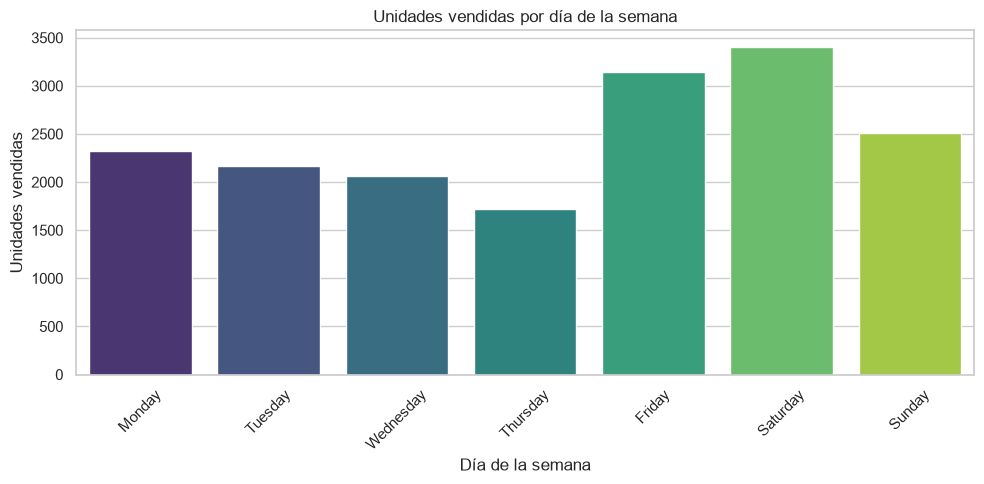

In [53]:
# Trazabilidad 13 - Visualización de unidades vendidas por día de la semana
weekday_sales = (
    df.groupby('dia_semana')['unidades_vendidas']
    .sum()
    .reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
    .reset_index()
)
weekday_sales = weekday_sales.rename(columns={'index':'dia_semana'})

plt.figure(figsize=(10, 5))
sns.set_theme(style='whitegrid')
sns.barplot(data=weekday_sales, x='dia_semana', y='unidades_vendidas', palette='viridis')
plt.title('Unidades vendidas por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### ANALISIS EXPLORATORIO COMPLETO DE df
A continuacion se presentan los diferentes analisis y visualizaciones para entender el comportamiento de las ventas y la competencia

In [57]:
# Trazabilidad 14 - Preparación del dataframe unificado para análisis exploratorio
ventas_df = df_ventas.copy()
competencia_df = df_competencia.copy()

ventas_df['fecha'] = pd.to_datetime(ventas_df['fecha'], errors='coerce')
competencia_df['fecha'] = pd.to_datetime(competencia_df['fecha'], errors='coerce')

df = ventas_df.merge(competencia_df, on=['fecha', 'producto_id'], how='inner')

df['anio'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['dia_mes'] = df['fecha'].dt.day
df['dia_semana'] = df['fecha'].dt.day_name()

print('Forma del dataframe unido:', df.shape)
print('Rango de fechas:', df['fecha'].min(), 'a', df['fecha'].max())
print('Productos únicos:', df['producto_id'].nunique())
print('Categorías:', sorted(df['categoria'].unique().tolist()))
print('Subcategorías:', sorted(df['subcategoria'].unique().tolist()))
print('\nResumen numérico:')
print(df[['precio_base', 'precio_venta', 'unidades_vendidas', 'ingresos', 'Amazon', 'Decathlon', 'Deporvillage']].describe().T)
print('\nNulos por columna:')
print(df.isnull().sum())
print('\nEjemplo de variables temporales:')
# Trazabilidad 14 - Preparación del dataframe unificado para análisis exploratorio
ventas_df = df_ventas.copy()
competencia_df = df_competencia.copy()

ventas_df['fecha'] = pd.to_datetime(ventas_df['fecha'], errors='coerce')
competencia_df['fecha'] = pd.to_datetime(competencia_df['fecha'], errors='coerce')

df = ventas_df.merge(competencia_df, on=['fecha', 'producto_id'], how='inner')

df['anio'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['dia_mes'] = df['fecha'].dt.day
df['dia_semana'] = df['fecha'].dt.day_name()

print('Forma del dataframe unido:', df.shape)
print('Rango de fechas:', df['fecha'].min(), 'a', df['fecha'].max())
print('Productos únicos:', df['producto_id'].nunique())
print('Categorías:', sorted(df['categoria'].unique().tolist()))
print('Subcategorías:', sorted(df['subcategoria'].unique().tolist()))
print('\nResumen numérico:')
print(df[['precio_base', 'precio_venta', 'unidades_vendidas', 'ingresos', 'Amazon', 'Decathlon', 'Deporvillage']].describe().T)
print('\nNulos por columna:')
print(df.isnull().sum())
print('\nEjemplo de variables temporales:')
print(df[['fecha', 'anio', 'mes', 'dia_mes', 'dia_semana']].head(10))

Forma del dataframe unido: (3552, 17)
Rango de fechas: 2021-10-25 00:00:00 a 2024-11-30 00:00:00
Productos únicos: 24
Categorías: ['Fitness', 'Outdoor', 'Running', 'Wellness']
Subcategorías: ['Banco Gimnasio', 'Bandas Elásticas', 'Bicicleta Montaña', 'Bloque Yoga', 'Cojín Yoga', 'Esterilla Fitness', 'Esterilla Yoga', 'Mancuernas Ajustables', 'Mochila Trekking', 'Pesa Rusa', 'Pesas Casa', 'Rodillera Yoga', 'Ropa Montaña', 'Ropa Running', 'Zapatillas Running', 'Zapatillas Trail']

Resumen numérico:
                    count        mean          std    min       25%      50%  \
precio_base        3552.0  123.125000   165.576753  20.00   48.7500   72.500   
precio_venta       3552.0  121.816546   164.017963  19.00   47.2125   71.810   
unidades_vendidas  3552.0    4.878660     6.311020   1.00    2.0000    3.000   
ingresos           3552.0  605.972323  1079.071192  19.46  131.5350  216.570   
Amazon             3552.0  118.623407   156.095628  16.85   47.1175   73.180   
Decathlon         

In [58]:
df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,Amazon,Decathlon,Deporvillage,anio,mes,dia_mes,dia_semana
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,82.96,111.88,97.43,2021,10,25,Monday
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,112.56,108.61,115.58,2021,10,25,Monday
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,79.79,78.44,80.11,2021,10,25,Monday
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,72.60,67.29,74.45,2021,10,25,Monday
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,37.71,33.60,33.07,2021,10,25,Monday


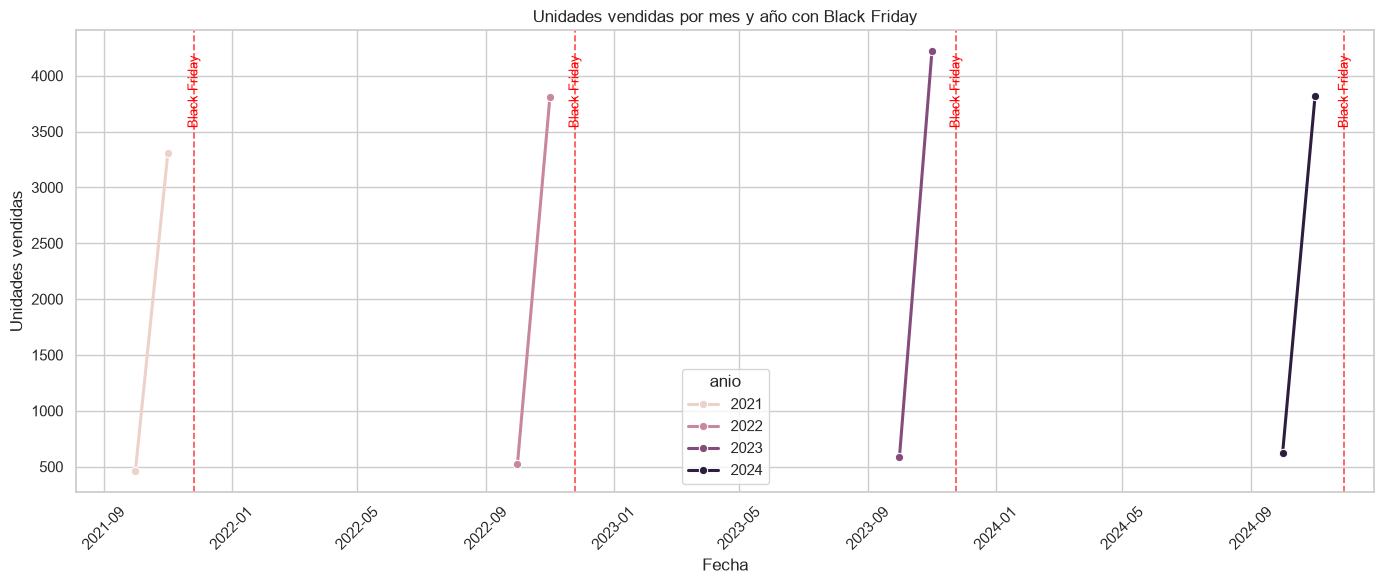

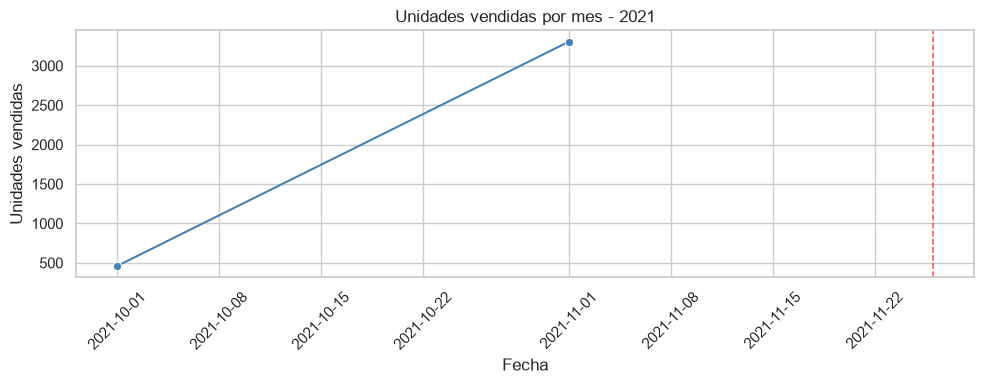

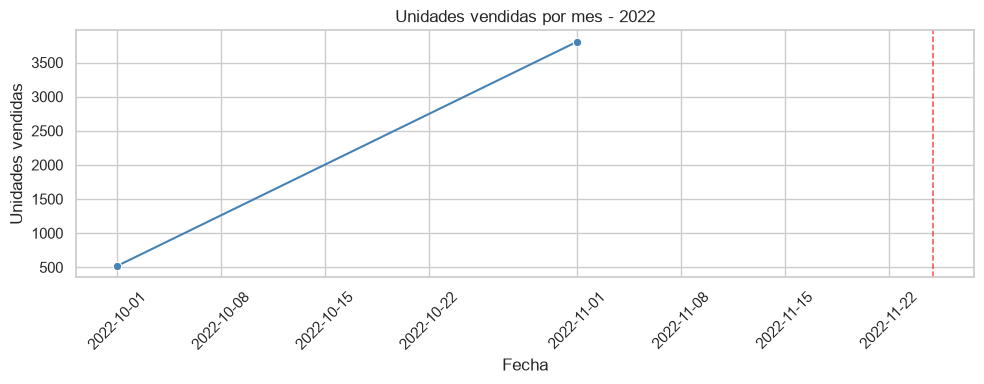

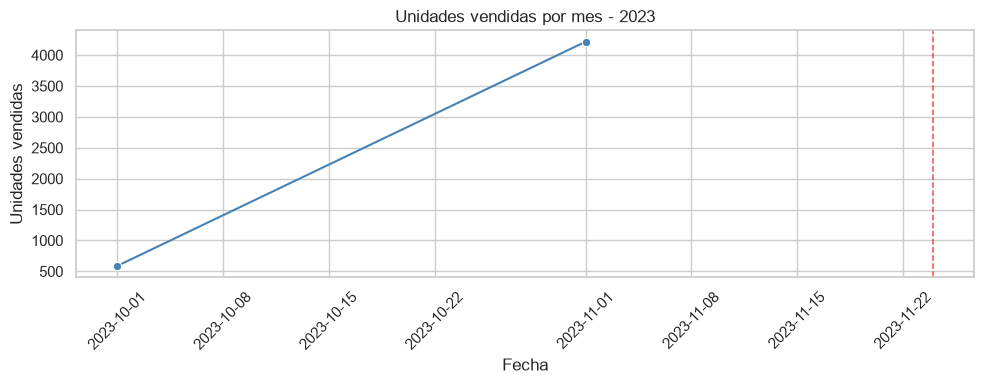

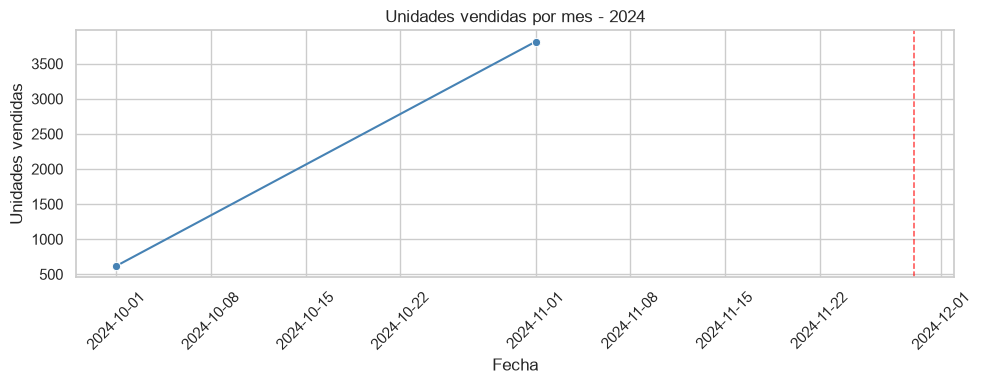

In [59]:
# Trazabilidad 15 - Análisis temporal por año con marcadores de Black Friday
# Black Friday suele caer en noviembre, pero se marca solo en fechas exactas de Black Friday (viernes después del Día de Acción de Gracias)
from pandas.tseries.offsets import DateOffset

# Crear una columna para eventos de Black Friday por año
black_friday_dates = []
for year in sorted(df['anio'].unique()):
    # El día de Thanksgiving en EE.UU. es el cuarto jueves de noviembre
    thanksgiving = pd.Timestamp(year, 11, 1) + DateOffset(weekday=3, weeks=3)
    black_friday = thanksgiving + pd.Timedelta(days=1)
    black_friday_dates.append(black_friday)

black_friday_dates = pd.to_datetime(black_friday_dates)

# Agregar una serie mensual agregada por año
series_temporal = (
    df.groupby(['anio', df['fecha'].dt.to_period('M').dt.to_timestamp()])['unidades_vendidas']
    .sum()
    .reset_index()
)
series_temporal = series_temporal.rename(columns={'fecha':'fecha_mes'})

plt.figure(figsize=(14, 6))
sns.set_theme(style='whitegrid')
ax = sns.lineplot(data=series_temporal, x='fecha_mes', y='unidades_vendidas', hue='anio', marker='o', linewidth=2.2)
for bf in black_friday_dates:
    ax.axvline(bf, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
    ax.text(bf, ax.get_ylim()[1]*0.95, 'Black Friday', rotation=90, va='top', ha='center', color='red', fontsize=9)
ax.set_title('Unidades vendidas por mes y año con Black Friday')
ax.set_xlabel('Fecha')
ax.set_ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot separado por año
for year in sorted(df['anio'].unique()):
    data_year = series_temporal[series_temporal['anio'] == year].copy()
    plt.figure(figsize=(10, 4))
    sns.lineplot(data=data_year, x='fecha_mes', y='unidades_vendidas', marker='o', color='steelblue')
    bf = black_friday_dates[black_friday_dates.year == year]
    for date in bf:
        plt.axvline(date, color='red', linestyle='--', linewidth=1.1, alpha=0.7)
    plt.title(f'Unidades vendidas por mes - {year}')
    plt.xlabel('Fecha')
    plt.ylabel('Unidades vendidas')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

C:\Users\andre\AppData\Local\Temp\ipykernel_24420\3308258954.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weekday_sales, x='dia_semana', y='unidades_vendidas', palette='viridis')


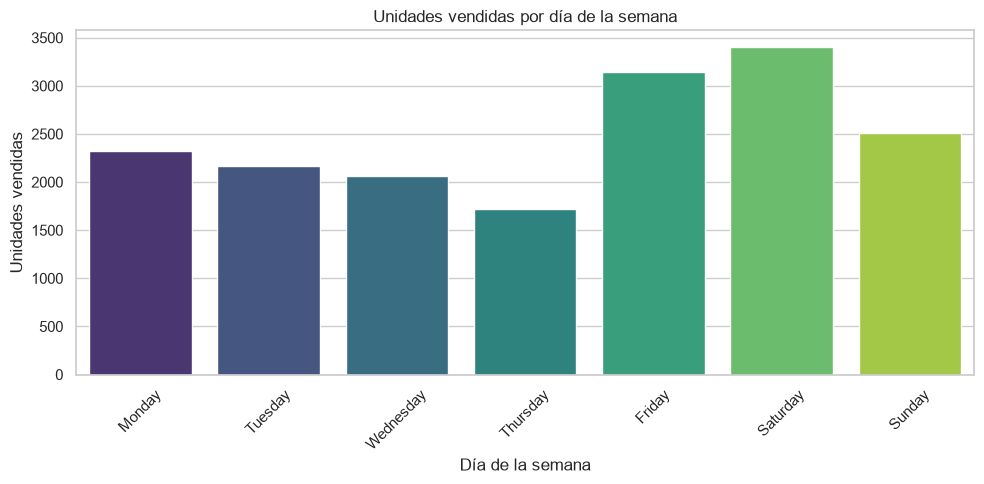

In [60]:
# Trazabilidad 16 - Visualización de ventas por día de la semana
weekday_sales = (
    df.groupby('dia_semana')['unidades_vendidas']
    .sum()
    .reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.set_theme(style='whitegrid')
sns.barplot(data=weekday_sales, x='dia_semana', y='unidades_vendidas', palette='viridis')
plt.title('Unidades vendidas por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

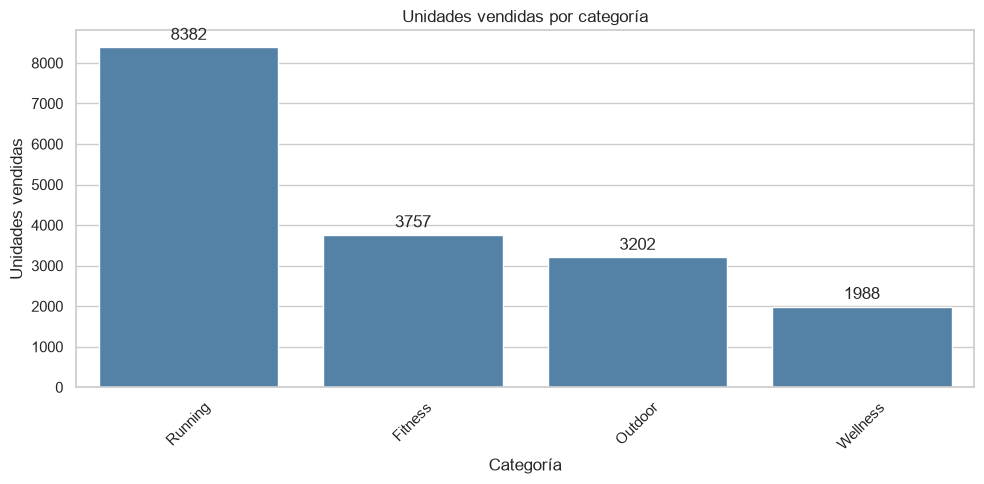

In [61]:
# Trazabilidad 17 - Visualización de ventas por categoría
category_sales = df.groupby('categoria')['unidades_vendidas'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.set_theme(style='whitegrid')
ax = sns.barplot(data=category_sales, x='categoria', y='unidades_vendidas', color='steelblue')

# Agregar etiquetas de datos en cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.title('Unidades vendidas por categoría')
plt.xlabel('Categoría')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\andre\AppData\Local\Temp\ipykernel_24420\3914367288.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subcategory_sales, x='unidades_vendidas', y='subcategoria', palette='rocket', orient='h')


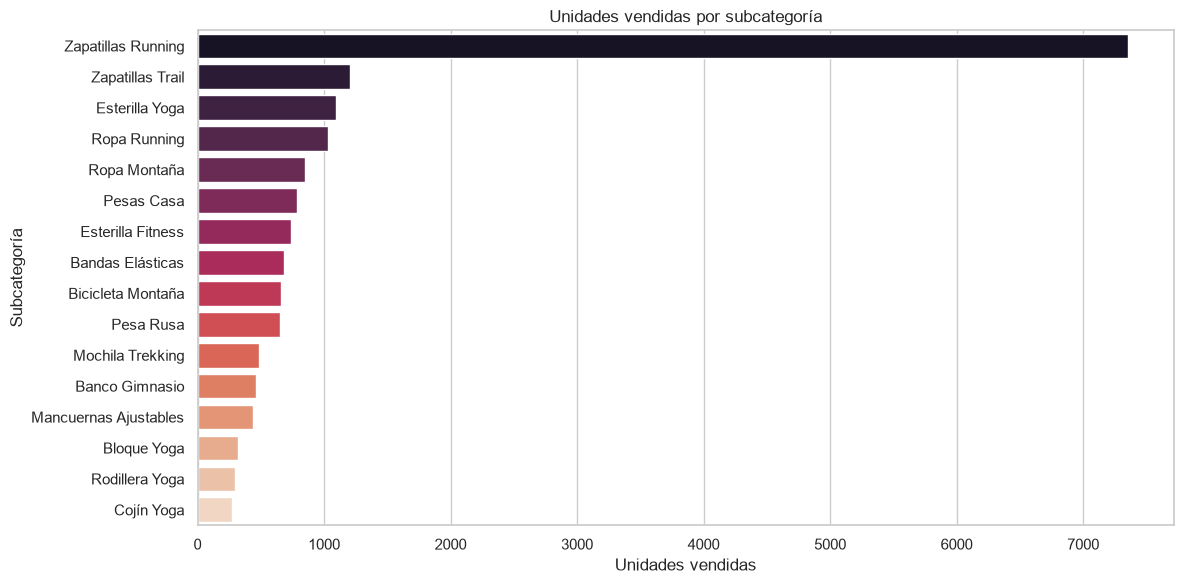

In [62]:
# Trazabilidad 18 - Visualización de ventas por subcategoría
subcategory_sales = df.groupby('subcategoria')['unidades_vendidas'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.set_theme(style='whitegrid')
sns.barplot(data=subcategory_sales, x='unidades_vendidas', y='subcategoria', palette='rocket', orient='h')
plt.title('Unidades vendidas por subcategoría')
plt.xlabel('Unidades vendidas')
plt.ylabel('Subcategoría')
plt.tight_layout()
plt.show()

C:\Users\andre\AppData\Local\Temp\ipykernel_24420\2670749611.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_sales, x='unidades_vendidas', y='nombre', palette='deep', orient='h')


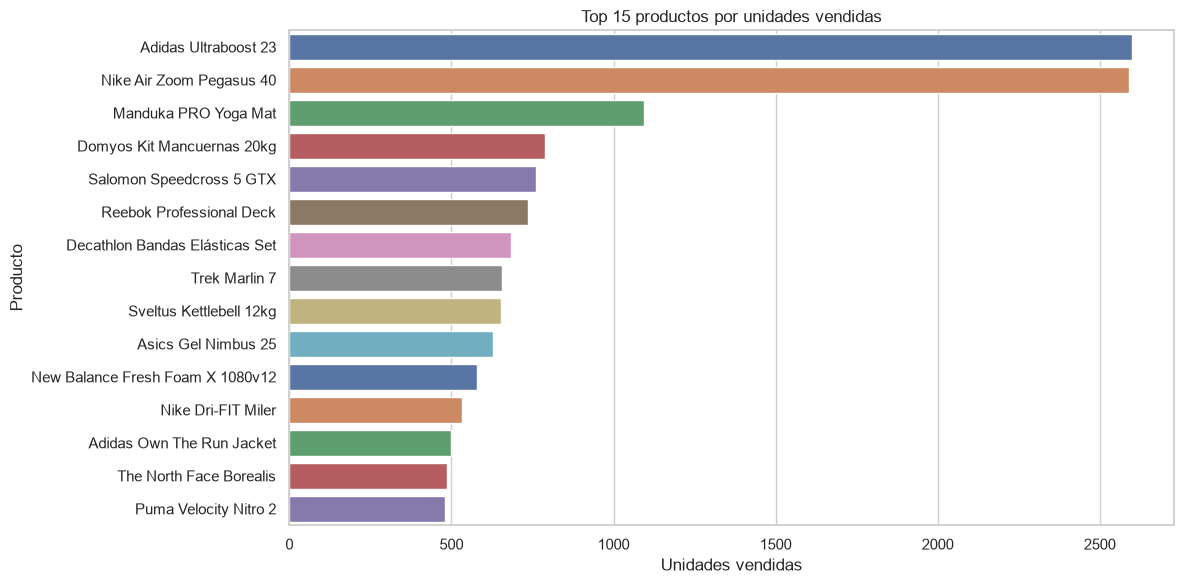

In [63]:
# Trazabilidad 19 - Identificación del top 15 de productos por unidades vendidas
product_sales = df.groupby('nombre')['unidades_vendidas'].sum().sort_values(ascending=False).head(15).reset_index()

plt.figure(figsize=(12, 6))
sns.set_theme(style='whitegrid')
sns.barplot(data=product_sales, x='unidades_vendidas', y='nombre', palette='deep', orient='h')
plt.title('Top 15 productos por unidades vendidas')
plt.xlabel('Unidades vendidas')
plt.ylabel('Producto')
plt.tight_layout()
plt.show()

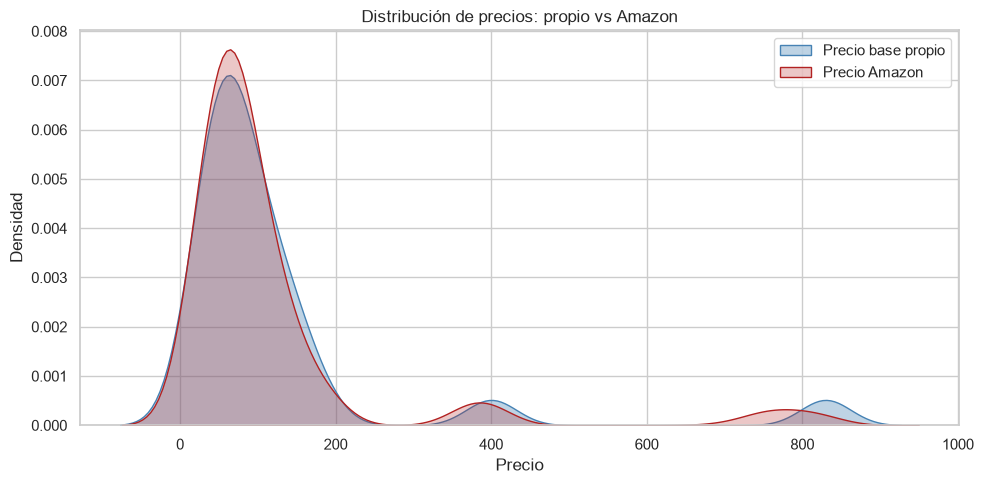

C:\Users\andre\AppData\Local\Temp\ipykernel_24420\3264690876.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[['precio_base','Amazon']].melt(), x='variable', y='value', palette=['steelblue','firebrick'])


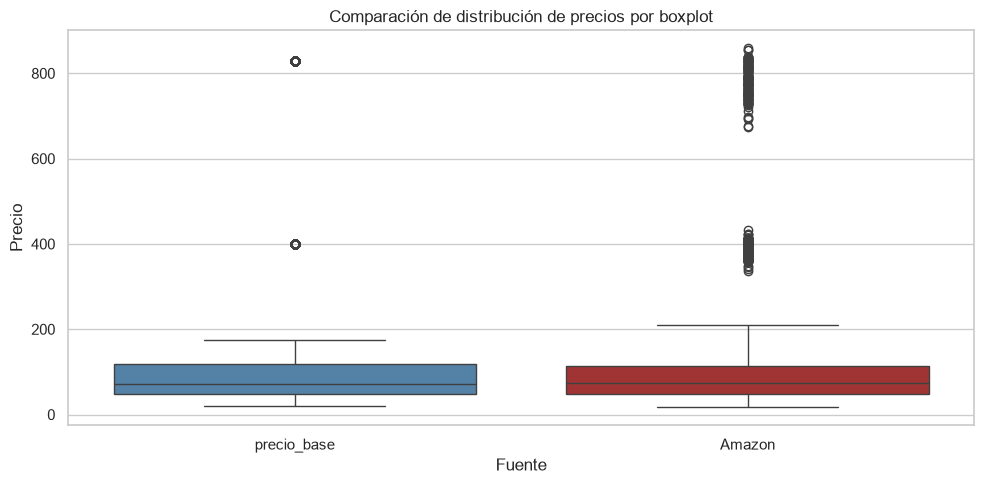

In [64]:
# Trazabilidad 20 - Comparación de distribución de precios propio vs competencia
plt.figure(figsize=(10, 5))
sns.set_theme(style='whitegrid')
sns.kdeplot(data=df, x='precio_base', fill=True, color='steelblue', alpha=0.35, label='Precio base propio')
sns.kdeplot(data=df, x='Amazon', fill=True, color='firebrick', alpha=0.25, label='Precio Amazon')
plt.title('Distribución de precios: propio vs Amazon')
plt.xlabel('Precio')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()

# Comparación adicional por boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['precio_base','Amazon']].melt(), x='variable', y='value', palette=['steelblue','firebrick'])
plt.title('Comparación de distribución de precios por boxplot')
plt.xlabel('Fuente')
plt.ylabel('Precio')
plt.tight_layout()
plt.show()

In [65]:
# Trazabilidad 21 - Ingeniería de variables temporales, lags y características de negocio
import pandas as pd
import numpy as np
import holidays
from pandas.tseries.offsets import DateOffset

if 'df' not in globals():
    ventas_df = pd.read_csv('../data/raw/entrenamiento/ventas.csv')
    competencia_df = pd.read_csv('../data/raw/entrenamiento/competencia.csv')
    ventas_df['fecha'] = pd.to_datetime(ventas_df['fecha'], errors='coerce')
    competencia_df['fecha'] = pd.to_datetime(competencia_df['fecha'], errors='coerce')
    df = ventas_df.merge(competencia_df, on=['fecha', 'producto_id'], how='inner')

# Crear variables temporales sobre el dataframe actual
if 'fecha' in df.columns:
    df = df.copy()
    df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
    df = df.sort_values(['producto_id', 'fecha'], kind='mergesort').reset_index(drop=True)

    df['anio'] = df['fecha'].dt.year
    df['mes'] = df['fecha'].dt.month
    df['dia_mes'] = df['fecha'].dt.day
    df['dia_semana'] = df['fecha'].dt.day_name()
    df['es_fin_semana'] = df['fecha'].dt.dayofweek.isin([5, 6]).astype(bool)

    isocalendar = df['fecha'].dt.isocalendar()
    df['semana_del_año'] = isocalendar.week.astype(int)
    df['dia_del_año'] = df['fecha'].dt.dayofyear
    df['trimestre'] = df['fecha'].dt.quarter
    df['es_inicio_mes'] = (df['fecha'].dt.day == 1).astype(bool)
    df['es_fin_mes'] = df['fecha'].dt.is_month_end.astype(bool)
    df['es_primera_quincena'] = (df['fecha'].dt.day <= 15).astype(bool)

    meses = {
        1: 'enero', 2: 'febrero', 3: 'marzo', 4: 'abril', 5: 'mayo', 6: 'junio',
        7: 'julio', 8: 'agosto', 9: 'septiembre', 10: 'octubre', 11: 'noviembre', 12: 'diciembre'
    }
    df['mes_nombre'] = df['mes'].map(meses)
    df['temporada'] = np.select(
        [df['mes'].isin([12, 1, 2]), df['mes'].isin([3, 4, 5]), df['mes'].isin([6, 7, 8]), df['mes'].isin([9, 10, 11])],
        ['verano', 'otoño', 'invierno', 'primavera'],
        default='desconocida'
    )

    # Festivos de Colombia
    years = sorted(df['anio'].dropna().astype(int).unique())
    co_holidays = holidays.country_holidays('CO', years=years, language='es')
    holiday_lookup = {pd.Timestamp(key).normalize(): value for key, value in co_holidays.items()}
    df['nombre_festivo'] = df['fecha'].dt.normalize().map(holiday_lookup).fillna('')
    df['es_festivo'] = df['nombre_festivo'].ne('').astype(bool)

    # Black Friday y Cyber Monday
    def marcar_eventos_comerciales(fecha):
        thanksgiving = pd.Timestamp(fecha.year, 11, 1) + DateOffset(weekday=3, weeks=3)
        black_friday = thanksgiving + pd.Timedelta(days=1)
        cyber_monday = thanksgiving + pd.Timedelta(days=3)
        return bool(fecha == black_friday), bool(fecha == cyber_monday)

    resultados = df['fecha'].apply(marcar_eventos_comerciales)
    df['es_black_friday'] = resultados.apply(lambda x: x[0]).astype(bool)
    df['es_cyber_monday'] = resultados.apply(lambda x: x[1]).astype(bool)

    # Crear variable de descuento porcentual
    df['descuento_porcentaje'] = ((df['precio_venta'] - df['precio_base']) / df['precio_base'] * 100)
    df['descuento_porcentaje'] = df['descuento_porcentaje'].replace([np.inf, -np.inf], np.nan)

    # Lags de unidades vendidas por producto y año
    df = df.sort_values(['producto_id', 'anio', 'fecha'], kind='mergesort').reset_index(drop=True)
    for lag in range(1, 8):
        df[f'lag_{lag}_unidades'] = df.groupby(['producto_id', 'anio'])['unidades_vendidas'].shift(lag)

    df['media_movil_7d_unidades'] = df.groupby(['producto_id', 'anio'])['unidades_vendidas'].transform(
        lambda s: s.rolling(window=7, min_periods=7).mean()
    )

    feature_columns = [f'lag_{lag}_unidades' for lag in range(1, 8)] + ['media_movil_7d_unidades']
    df = df.dropna(subset=feature_columns + ['descuento_porcentaje']).reset_index(drop=True)

print(df[['fecha', 'producto_id', 'anio', 'mes', 'dia_mes', 'dia_semana', 'es_fin_semana', 'es_festivo', 'es_black_friday', 'es_cyber_monday', 'semana_del_año', 'trimestre', 'mes_nombre', 'temporada'] + feature_columns].head(10))
print('Filas finales después de limpiar:', df.shape[0])

       fecha producto_id  anio  mes  dia_mes dia_semana  es_fin_semana  \
0 2021-11-01    PROD_001  2021   11        1     Monday          False   
1 2021-11-02    PROD_001  2021   11        2    Tuesday          False   
2 2021-11-03    PROD_001  2021   11        3  Wednesday          False   
3 2021-11-04    PROD_001  2021   11        4   Thursday          False   
4 2021-11-05    PROD_001  2021   11        5     Friday          False   
5 2021-11-06    PROD_001  2021   11        6   Saturday           True   
6 2021-11-07    PROD_001  2021   11        7     Sunday           True   
7 2021-11-08    PROD_001  2021   11        8     Monday          False   
8 2021-11-09    PROD_001  2021   11        9    Tuesday          False   
9 2021-11-10    PROD_001  2021   11       10  Wednesday          False   

   es_festivo  es_black_friday  es_cyber_monday  ...  mes_nombre  temporada  \
0        True            False            False  ...   noviembre  primavera   
1       False            Fa

In [66]:
# Trazabilidad 22 - Verificación de la forma final del dataframe procesado
df.shape

(2880, 39)

In [67]:
# Trazabilidad 23 - Revisión del contenido final del dataframe
df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,es_cyber_monday,descuento_porcentaje,lag_1_unidades,lag_2_unidades,lag_3_unidades,lag_4_unidades,lag_5_unidades,lag_6_unidades,lag_7_unidades,media_movil_7d_unidades
0,2021-11-01,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,7,115.07,805.49,...,False,0.060870,9.0,12.0,12.0,7.0,8.0,8.0,6.0,9.000000
1,2021-11-02,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,10,116.10,1161.00,...,False,0.956522,7.0,9.0,12.0,12.0,7.0,8.0,8.0,9.285714
2,2021-11-03,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,11,114.58,1260.38,...,False,-0.365217,10.0,7.0,9.0,12.0,12.0,7.0,8.0,9.714286
3,2021-11-04,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,12,112.23,1346.76,...,False,-2.408696,11.0,10.0,7.0,9.0,12.0,12.0,7.0,10.428571
4,2021-11-05,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,10,113.81,1138.10,...,False,-1.034783,12.0,11.0,10.0,7.0,9.0,12.0,12.0,10.142857


In [68]:
# Trazabilidad 24 - Verificación de la cantidad de registros por año
df.groupby("anio").size()

anio
2021    720
2022    720
2023    720
2024    720
dtype: int64

In [69]:
# Cálculo de precio promedio de competencia y ratio de precio
df = ventas_df.merge(
    competencia_df,
    on=['fecha', 'producto_id'],
    how='inner'
)

df['precio_competencia'] = df[['Amazon', 'Decathlon', 'Deporvillage']].mean(axis=1)
df['ratio_precio'] = np.where(
    df['precio_competencia'] != 0,
    df['precio_base'] / df['precio_competencia'],
    np.nan
)

df = df.drop(columns=['Amazon', 'Decathlon', 'Deporvillage'])
df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,precio_competencia,ratio_precio
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,97.423333,1.180415
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,112.250000,1.202673
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,79.446667,1.069900
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,71.446667,1.049734
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,34.793333,1.005940


In [70]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   fecha               3552 non-null   datetime64[us]
 1   producto_id         3552 non-null   str           
 2   nombre              3552 non-null   str           
 3   categoria           3552 non-null   str           
 4   subcategoria        3552 non-null   str           
 5   precio_base         3552 non-null   int64         
 6   es_estrella         3552 non-null   bool          
 7   unidades_vendidas   3552 non-null   int64         
 8   precio_venta        3552 non-null   float64       
 9   ingresos            3552 non-null   float64       
 10  precio_competencia  3552 non-null   float64       
 11  ratio_precio        3552 non-null   float64       
dtypes: bool(1), datetime64[us](1), float64(4), int64(2), str(4)
memory usage: 488.6 KB


In [71]:
# Crear copias de variables categóricas con sufijo _h
if 'nombre_h' not in df.columns:
    df['nombre_h'] = df['nombre']
if 'categoria_h' not in df.columns:
    df['categoria_h'] = df['categoria']
if 'subcategoria_h' not in df.columns:
    df['subcategoria_h'] = df['subcategoria']

# One-hot encoding sobre las columnas creadas
encoded_df = pd.get_dummies(df, columns=['nombre_h', 'categoria_h', 'subcategoria_h'], dtype=int)
encoded_df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,subcategoria_h_Esterilla Yoga,subcategoria_h_Mancuernas Ajustables,subcategoria_h_Mochila Trekking,subcategoria_h_Pesa Rusa,subcategoria_h_Pesas Casa,subcategoria_h_Rodillera Yoga,subcategoria_h_Ropa Montaña,subcategoria_h_Ropa Running,subcategoria_h_Zapatillas Running,subcategoria_h_Zapatillas Trail
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,...,0,0,0,0,0,0,0,0,1,0
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,...,0,0,0,0,0,0,0,0,1,0
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,...,0,0,0,0,0,0,0,0,1,0
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,...,0,0,0,0,0,0,0,0,1,0
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,...,0,0,0,0,0,0,0,1,0,0


In [73]:
# Guardar el DataFrame encoded_df en la carpeta data/processed con el nombre df
encoded_df.to_csv('../data/processed/df.csv', index=False)
encoded_df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,subcategoria_h_Esterilla Yoga,subcategoria_h_Mancuernas Ajustables,subcategoria_h_Mochila Trekking,subcategoria_h_Pesa Rusa,subcategoria_h_Pesas Casa,subcategoria_h_Rodillera Yoga,subcategoria_h_Ropa Montaña,subcategoria_h_Ropa Running,subcategoria_h_Zapatillas Running,subcategoria_h_Zapatillas Trail
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,...,0,0,0,0,0,0,0,0,1,0
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,...,0,0,0,0,0,0,0,0,1,0
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,...,0,0,0,0,0,0,0,0,1,0
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,...,0,0,0,0,0,0,0,0,1,0
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
encoded_df.columns